# Projet ML — California Housing Prices
**Auteur** : Michée SOGBOSSI  
**Formation** : M1 Intelligence Artificielle — Ynov Toulouse 2025-2026

---
**Objectif** : Prédire le prix médian des habitations dans les districts californiens.  
Pipeline complet : exploration → préparation → modèles ensemblistes → ACP.

## 0. Imports & Configuration

In [2]:
import os, sys, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    BaggingRegressor, ExtraTreesRegressor,
    AdaBoostRegressor, StackingRegressor,
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Charger la config
from config import (
    DATA_PATH, FIGURES_DIR, TARGET_COL, TEST_SIZE, RANDOM_STATE,
    NUM_FEATURES, CAT_FEATURES,
    RF_N_ESTIMATORS, GB_N_ESTIMATORS, GB_LEARNING_RATE, GB_MAX_DEPTH,
    ADA_N_ESTIMATORS, PCA_VARIANCE_THRESHOLD,
)

os.makedirs(FIGURES_DIR, exist_ok=True)
print('✓ Imports OK')

✓ Imports OK


## 1. Chargement & Exploration des données

In [3]:
df = pd.read_csv(DATA_PATH, sep=';')
print(f'Shape : {df.shape}')
df.head()

Shape : (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
print('Statistiques descriptives :')
display(df.describe())
print('\nValeurs manquantes :')
display(df.isnull().sum())

Statistiques descriptives :


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000



Valeurs manquantes :


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## 2. Visualisation

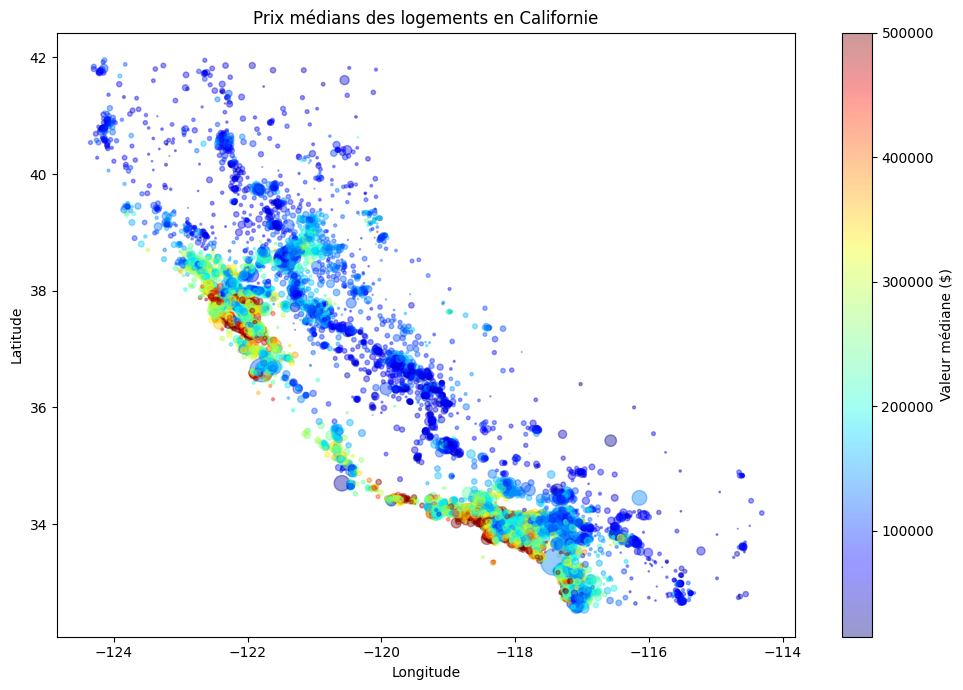

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(df['longitude'], df['latitude'],
                c=df[TARGET_COL], cmap='jet', alpha=0.4,
                s=df['population']/100,
                vmin=df[TARGET_COL].min(), vmax=df[TARGET_COL].max())
plt.colorbar(sc, ax=ax, label='Valeur médiane ($)')
ax.set(xlabel='Longitude', ylabel='Latitude',
       title='Prix médians des logements en Californie')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'geo_visualisation.png'), dpi=100, bbox_inches='tight')
plt.show()

Corrélations avec median_house_value :


median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

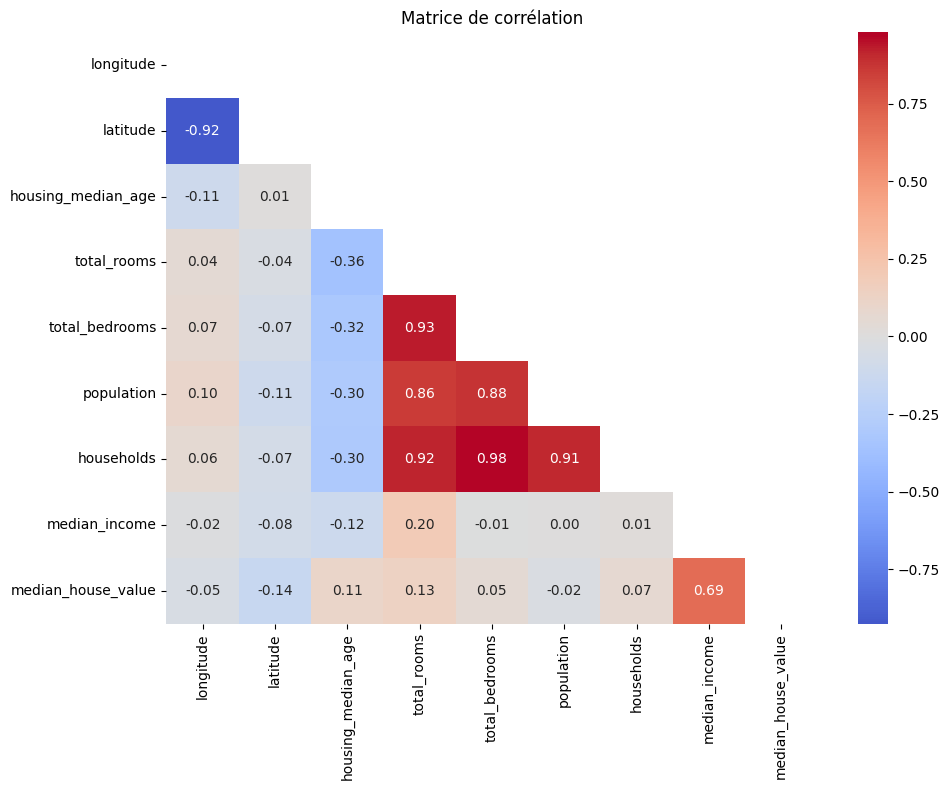

In [6]:
corr = df.select_dtypes(include=np.number).corr()
print('Corrélations avec', TARGET_COL, ':')
display(corr[TARGET_COL].sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matrice de corrélation')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'correlation_matrix.png'), dpi=100, bbox_inches='tight')
plt.show()

## 3. Préparation des données

In [7]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ]), NUM_FEATURES),
    ('cat', Pipeline([
        ('encoder', OrdinalEncoder()),
    ]), CAT_FEATURES),
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)
print('✓ Prétraitement appliqué')

Train : (16512, 9)  |  Test : (4128, 9)
✓ Prétraitement appliqué


## 4. Modèles — Baseline & Ensemblistes

In [8]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:<35} RMSE: {rmse:>10.2f}  MAE: {mae:>10.2f}  R²: {r2:.4f}')
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = {}

# Baseline
print('[BASELINE]')
lr = LinearRegression().fit(X_train_prep, y_train)
results['Régression Linéaire (base)'] = evaluate('Régression Linéaire (base)', y_test, lr.predict(X_test_prep))

# Bagging
print('\n[BAGGING]')
rf = RandomForestRegressor(n_estimators=RF_N_ESTIMATORS, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train_prep, y_train)
results['Random Forest'] = evaluate('Random Forest', y_test, rf.predict(X_test_prep))

et = ExtraTreesRegressor(n_estimators=RF_N_ESTIMATORS, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train_prep, y_train)
results['Extra Trees'] = evaluate('Extra Trees', y_test, et.predict(X_test_prep))

bag = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=RF_N_ESTIMATORS, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train_prep, y_train)
results['Bagging (Decision Tree)'] = evaluate('Bagging (Decision Tree)', y_test, bag.predict(X_test_prep))

# Boosting
print('\n[BOOSTING]')
gb = GradientBoostingRegressor(n_estimators=GB_N_ESTIMATORS, learning_rate=GB_LEARNING_RATE, max_depth=GB_MAX_DEPTH, random_state=RANDOM_STATE).fit(X_train_prep, y_train)
results['Gradient Boosting'] = evaluate('Gradient Boosting', y_test, gb.predict(X_test_prep))

ada = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=4), n_estimators=ADA_N_ESTIMATORS, random_state=RANDOM_STATE).fit(X_train_prep, y_train)
results['AdaBoost'] = evaluate('AdaBoost', y_test, ada.predict(X_test_prep))

# Stacking
print('\n[STACKING]')
stacking = StackingRegressor(
    estimators=[('lr', LinearRegression()),
                ('dt', DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)),
                ('rf', RandomForestRegressor(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1))],
    final_estimator=Ridge(), cv=5
).fit(X_train_prep, y_train)
results['Stacking (LR+DT+RF → Ridge)'] = evaluate('Stacking (LR+DT+RF → Ridge)', y_test, stacking.predict(X_test_prep))

[BASELINE]
  Régression Linéaire (base)          RMSE:   70474.28  MAE:   51639.73  R²: 0.6417

[BAGGING]
  Random Forest                       RMSE:   50353.76  MAE:   32433.11  R²: 0.8171
  Extra Trees                         RMSE:   52148.25  MAE:   34345.44  R²: 0.8038
  Bagging (Decision Tree)             RMSE:   50363.88  MAE:   32511.83  R²: 0.8170

[BOOSTING]
  Gradient Boosting                   RMSE:   50274.53  MAE:   34083.14  R²: 0.8177
  AdaBoost                            RMSE:   96479.54  MAE:   85068.10  R²: 0.3285

[STACKING]
  Stacking (LR+DT+RF → Ridge)         RMSE:   50332.69  MAE:   32386.39  R²: 0.8173


## 5. Comparaison des modèles

,RMSE,MAE,R2
Gradient Boosting,50274.53,34083.14,0.82
Stacking (LR+DT+RF → Ridge),50332.69,32386.39,0.82
Random Forest,50353.76,32433.11,0.82
Bagging (Decision Tree),50363.88,32511.83,0.82
Extra Trees,52148.25,34345.44,0.80
Régression Linéaire (base),70474.28,51639.73,0.64
AdaBoost,96479.54,85068.10,0.33


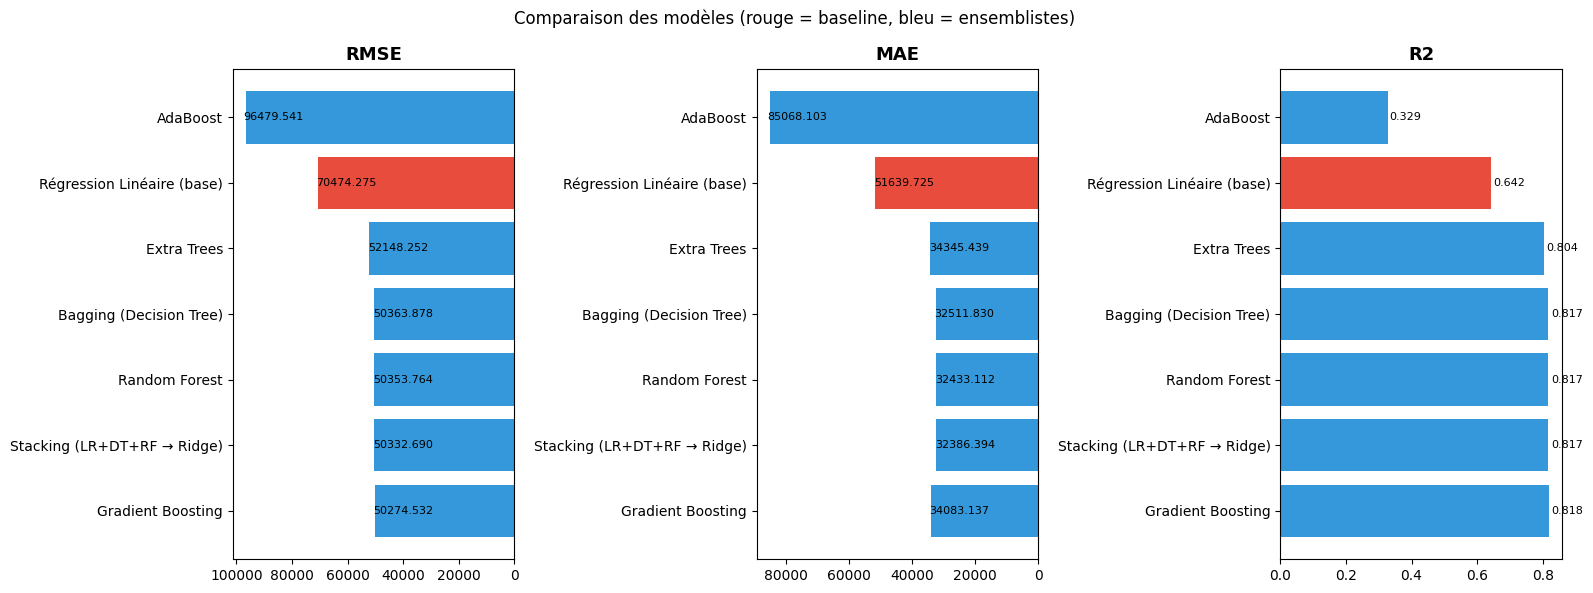

In [9]:
df_res = pd.DataFrame(results).T.sort_values('RMSE')
display(df_res.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
colors = ['#e74c3c' if 'base' in n else '#3498db' for n in df_res.index]
for metric, ax in zip(['RMSE', 'MAE', 'R2'], axes):
    bars = ax.barh(df_res.index, df_res[metric], color=colors)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    for bar, val in zip(bars, df_res[metric]):
        ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)
axes[0].invert_xaxis(); axes[1].invert_xaxis()
plt.suptitle('Comparaison des modèles (rouge = baseline, bleu = ensemblistes)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'model_comparison.png'), dpi=100, bbox_inches='tight')
plt.show()

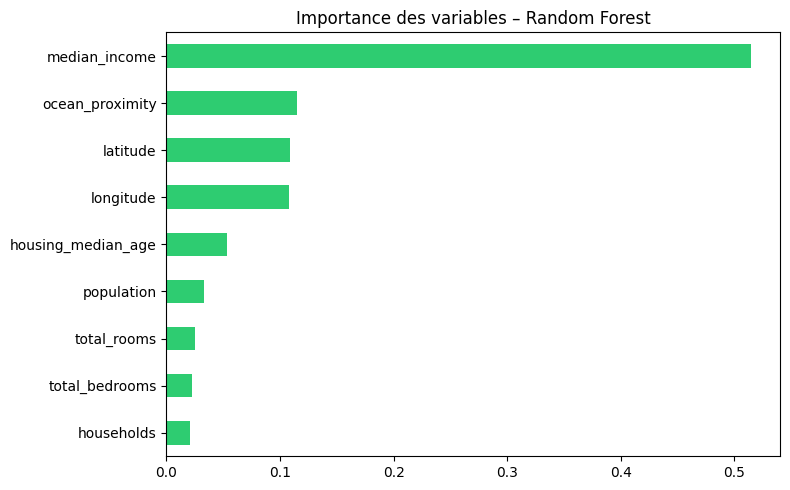

In [10]:
feat_imp = pd.Series(rf.feature_importances_, index=NUM_FEATURES+CAT_FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='#2ecc71')
ax.set_title('Importance des variables – Random Forest')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feature_importance.png'), dpi=100, bbox_inches='tight')
plt.show()

## 6. Bonus — Réduction Dimensionnelle (ACP / PCA)

Composantes pour 95% de variance : 5/9


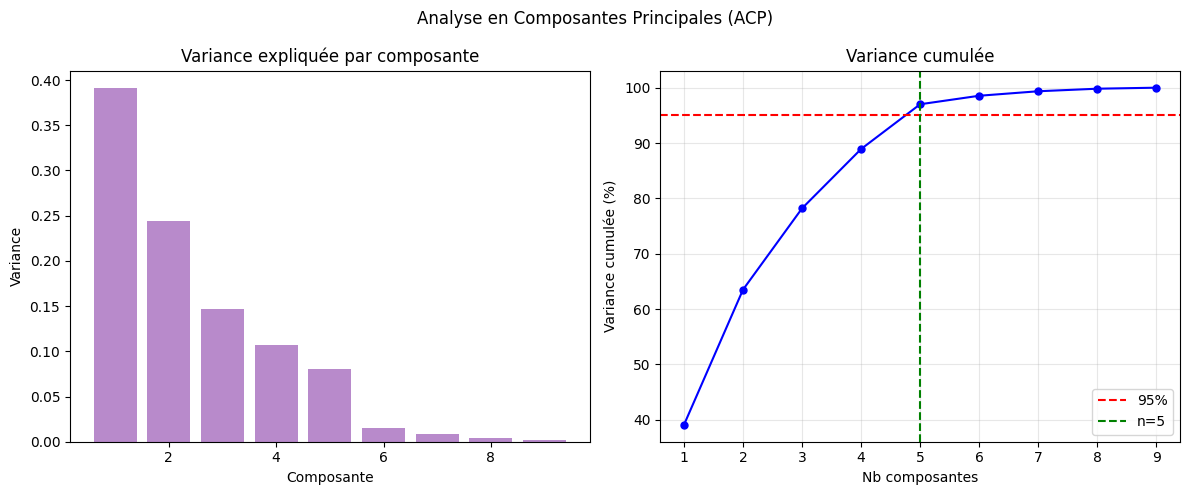

In [11]:
pca_full = PCA().fit(X_train_prep)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_comp = int(np.argmax(cumvar >= PCA_VARIANCE_THRESHOLD) + 1)
print(f'Composantes pour {PCA_VARIANCE_THRESHOLD*100:.0f}% de variance : {n_comp}/{X_train_prep.shape[1]}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1), pca_full.explained_variance_ratio_, color='#9b59b6', alpha=0.7)
axes[0].set(title='Variance expliquée par composante', xlabel='Composante', ylabel='Variance')
axes[1].plot(range(1, len(cumvar)+1), cumvar*100, 'b-o', markersize=5)
axes[1].axhline(y=95, color='r', linestyle='--', label='95%')
axes[1].axvline(x=n_comp, color='g', linestyle='--', label=f'n={n_comp}')
axes[1].set(title='Variance cumulée', xlabel='Nb composantes', ylabel='Variance cumulée (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('Analyse en Composantes Principales (ACP)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pca_analysis.png'), dpi=100, bbox_inches='tight')
plt.show()

In [13]:
pca = PCA(n_components=n_comp)
X_train_pca = pca.fit_transform(X_train_prep)
X_test_pca  = pca.transform(X_test_prep)
print(f'Shape après PCA : {X_train_pca.shape} (au lieu de {X_train_prep.shape})')

results_pca = {}
print(f'\nModèles avec PCA ({n_comp} composantes) :')
for name, model in [
    ('LR + PCA', LinearRegression()),
    ('Random Forest + PCA', RandomForestRegressor(n_estimators=RF_N_ESTIMATORS, random_state=RANDOM_STATE, n_jobs=-1)),
    ('Gradient Boosting + PCA', GradientBoostingRegressor(n_estimators=GB_N_ESTIMATORS, learning_rate=GB_LEARNING_RATE, max_depth=GB_MAX_DEPTH, random_state=RANDOM_STATE)),
    ('Stacking + PCA', StackingRegressor(
        estimators=[('lr', LinearRegression()),
                    ('dt', DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)),
                    ('rf', RandomForestRegressor(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1))],
        final_estimator=Ridge(), cv=5)),
]:
    model.fit(X_train_pca, y_train)
    results_pca[name] = evaluate(name, y_test, model.predict(X_test_pca))

Shape après PCA : (16512, 5) (au lieu de (16512, 9))

Modèles avec PCA (5 composantes) :
  LR + PCA                            RMSE:   80339.60  MAE:   60030.92  R²: 0.5344
  Random Forest + PCA                 RMSE:   63833.71  MAE:   43810.76  R²: 0.7061
  Gradient Boosting + PCA             RMSE:   65697.46  MAE:   45979.20  R²: 0.6886
  Stacking + PCA                      RMSE:   64178.78  MAE:   43916.42  R²: 0.7029


,RMSE sans PCA,RMSE avec PCA,R² sans PCA,R² avec PCA
Régression Linéaire,70474.275,80339.602,0.642,0.534
Random Forest,50353.764,63833.707,0.817,0.706
Gradient Boosting,50274.532,65697.457,0.818,0.689
Stacking,50332.690,64178.776,0.817,0.703


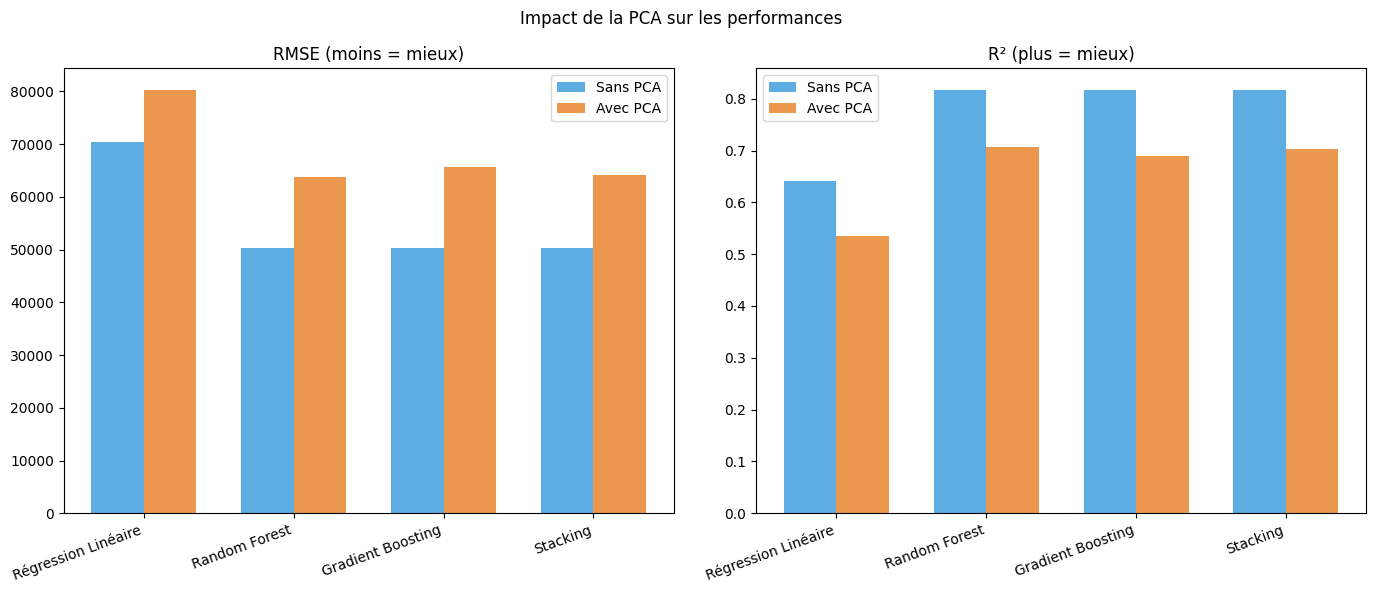

In [14]:
mapping = {
    'Régression Linéaire': ('Régression Linéaire (base)', 'LR + PCA'),
    'Random Forest':       ('Random Forest',              'Random Forest + PCA'),
    'Gradient Boosting':   ('Gradient Boosting',          'Gradient Boosting + PCA'),
    'Stacking':            ('Stacking (LR+DT+RF → Ridge)','Stacking + PCA'),
}
comp = {k: {'RMSE sans PCA': results[v[0]]['RMSE'], 'RMSE avec PCA': results_pca[v[1]]['RMSE'],
            'R² sans PCA':   results[v[0]]['R2'],   'R² avec PCA':   results_pca[v[1]]['R2']}
        for k, v in mapping.items()}
df_comp = pd.DataFrame(comp).T
display(df_comp.round(3))

x, w = np.arange(len(df_comp)), 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, m1, m2, title in zip(axes,
    ['RMSE sans PCA', 'R² sans PCA'], ['RMSE avec PCA', 'R² avec PCA'],
    ['RMSE (moins = mieux)', 'R² (plus = mieux)']):
    ax.bar(x-w/2, df_comp[m1], w, label='Sans PCA', color='#3498db', alpha=0.8)
    ax.bar(x+w/2, df_comp[m2], w, label='Avec PCA', color='#e67e22', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(df_comp.index, rotation=20, ha='right')
    ax.set_title(title, fontsize=12); ax.legend()
plt.suptitle('Impact de la PCA sur les performances')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pca_comparison.png'), dpi=100, bbox_inches='tight')
plt.show()

---
## Conclusion

- **Gradient Boosting** obtient le meilleur RMSE (50 275$) avec R² = 0.82
- Les méthodes ensemblistes réduisent le RMSE de **~28%** par rapport à la baseline linéaire
- La **PCA dégrade** légèrement les performances : les variables originales ont une valeur sémantique importante

---
*Michée SOGBOSSI — M1 IA — Ynov Toulouse 2025-2026*